## 1. Data Loading & Preprocessing (MedMNIST v2)

In this step, we prepare the dataset for the Diffusion Model.

**Dataset:**
We are using **PneumoniaMNIST** from the [MedMNIST v2 collection](https://medmnist.com/).
* **Source:** 5,856 Chest X-Rays.
* **Resolution:** We configure the loader to fetch **128x128** images (High-Res) instead of the default 28x28.
* **Classes:** 0 = Normal (Healthy), 1 = Pneumonia (Sick).

**Preprocessing Pipeline:**
1.  **Download:** Automatically fetches the `.npz` file if not present.
2.  **Normalization:** We scale pixel values from `[0, 1]` to `[-1, 1]`. This is standard for Diffusion Models (DDPM) to match the range of the Gaussian noise.
3.  **Modular Loading:** The code is wrapped in a `load_data()` function, allowing us to easily switch resolutions (e.g., `64x64` vs `128x128`) later without restarting the kernel.

# Pneumonia Detection Using Diffusion Models (DDPM & DDIM)
### Unsupervised Anomaly Detection on Chest X-Rays | By Sameera Viraj (March 2026)

---

## 📋 Project Overview

This project applies **Denoising Diffusion Probabilistic Models (DDPM)** and **Denoising Diffusion Implicit Models (DDIM)** to detect pneumonia in chest X-rays — without ever showing the model a single sick lung during training.

The core idea is elegant: train a generative model exclusively on **healthy lungs**, so it learns what a healthy lung "should" look like. Then, when a sick lung is passed through it, the model *forces* it back toward healthy — and the **difference** between the original (sick) and the reconstructed (healthy) image becomes the anomaly map that highlights infection.

This approach falls under **unsupervised anomaly detection**, and it is particularly powerful in medical imaging where labelled anomaly data is scarce.

---

## 📦 Dataset: PneumoniaMNIST (MedMNIST v2)

- **Source:** 5,856 pediatric chest X-rays from Guangzhou Women and Children's Medical Center.
- **Classes:** `0 = Normal (Healthy)` | `1 = Pneumonia (Sick)`
- **Resolution Used:** `128 × 128` pixels (upsampled from the default 28×28 for richer texture detail).
- **Normalization:** Pixel values are scaled from `[0, 255]` → `[-1, 1]`:

$$x_{\text{norm}} = \frac{x}{255} \times 2 - 1 = \frac{x - 127.5}{127.5}$$

This range is required by the diffusion process, which operates with zero-mean Gaussian noise.

> **Key Decision:** Only healthy images (`label = 0`) are used for **training**. The full test set (healthy + pneumonia) is used only for **evaluation**.

---

## ⚙️ Methods

### 1. Forward Diffusion Process (Adding Noise)

The forward process gradually corrupts a clean image $x_0$ by adding Gaussian noise over $T = 1000$ steps using a linear **noise schedule** ($\beta_1, \beta_2, \ldots, \beta_T$):

$$\beta_t = \text{linspace}(0.0001,\ 0.02,\ T)$$

Thanks to the reparameterization trick, we can jump directly to any noisy timestep $t$ in one step (closed-form):

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

where $\bar{\alpha}_t = \prod_{s=1}^{t}(1 - \beta_s)$ is the cumulative product of signal retention factors. This avoids running 1000 sequential steps during training.

---

### 2. U-Net: The Noise Prediction Network

A **U-Net** is used as the backbone. It takes a noisy image $x_t$ and a timestep $t$ as inputs, and predicts the noise $\epsilon$ that was added:

$$\hat{\epsilon} = \epsilon_\theta(x_t,\, t)$$

**Architecture highlights:**
- **Sinusoidal Time Embedding:** The scalar timestep $t$ is encoded into a meaningful vector using sinusoidal functions (inspired by transformers):
$$\text{emb}_i = \begin{cases} \sin(t \cdot \omega_i) & i < d/2 \\ \cos(t \cdot \omega_i) & i \geq d/2 \end{cases}, \quad \omega_i = e^{-\frac{\log 10000}{d/2-1} \cdot i}$$
This gives the model a smooth, continuous "sense of time" so it knows how much noise to expect at each step.

- **Encoder–Decoder with Skip Connections:** The encoder downsamples using `MaxPool2d`, and the decoder upsamples using nearest-neighbor interpolation. Skip connections preserve spatial detail lost during downsampling.
- **GroupNorm + SiLU Activation:** Each convolutional block uses `GroupNorm` (stable on small batches) and `SiLU` (Swish) activation, which outperforms ReLU in generative tasks.
- **Time Conditioning:** At every block, the time embedding is projected (via a linear layer) and added spatially to the feature maps, so every convolution is aware of the current noise level.

**Model capacity:** ~1M trainable parameters (990,209).

---

### 3. Training: Learning to Denoise

The model is trained to minimize the **Mean Squared Error (MSE)** between the true noise and the predicted noise:

$$\mathcal{L} = \mathbb{E}_{x_0, t, \epsilon}\left[\left\| \epsilon - \epsilon_\theta\!\left(\sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,\; t\right) \right\|^2\right]$$

**Training details:**
- Optimizer: `Adam` with learning rate `1e-4`
- Epochs: `50`
- Batch size: `64`
- At each step: sample a random image $x_0$, a random timestep $t \sim \mathcal{U}(0, T)$, and noise $\epsilon \sim \mathcal{N}(0, I)$.

---

### 4. DDPM Reverse Sampling (Stochastic)

To generate an image, we start from pure Gaussian noise $x_T \sim \mathcal{N}(0, I)$ and iteratively denoise using:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\,\epsilon_\theta(x_t, t)\right) + \sigma_t\, z, \quad z \sim \mathcal{N}(0,I)$$

where $\sigma_t = \sqrt{\frac{\beta_t(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}}$ is the **posterior variance** and $z = 0$ at the final step $t=0$.

This process is **stochastic** — each run produces a slightly different image, like sampling from the learned data distribution.

---

### 5. DDIM Reverse Sampling (Deterministic)

DDIM (Denoising Diffusion Implicit Models) offers a **faster, deterministic** alternative. Instead of sampling all 1000 steps, it uses a subset of $S \ll T$ steps:

$$x_{t_{\text{prev}}} = \sqrt{\bar{\alpha}_{t_{\text{prev}}}}\underbrace{\left(\frac{x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta}{\sqrt{\bar{\alpha}_t}}\right)}_{\hat{x}_0\text{ (estimated clean image)}} + \underbrace{\sqrt{1-\bar{\alpha}_{t_{\text{prev}}} - \sigma^2}\,\epsilon_\theta}_{\text{direction to }x_t} + \underbrace{\sigma_t\, z}_{\text{noise (}=0\text{ if }\eta=0\text{)}}$$

- Setting $\eta = 0$ → **fully deterministic** (same input always gives same output).
- Setting $\eta = 1$ → recovers DDPM behavior.
- Used here with `eta=0`, `steps=100`, making it ~10× faster than full DDPM sampling.

---

### 6. Anomaly Detection: The "Heal and Compare" Method

This is the medical application of the project. The pipeline for a single test image is:

1. **Pick** a test image $x_0$ (could be healthy or sick).
2. **Corrupt** it to timestep $t_{\text{start}}$ using the closed-form forward process (jump directly, no sequential steps needed).
3. **Heal** it back to $t = 0$ using the trained model (DDPM or DDIM reverse).
4. **Compute** the pixel-wise absolute difference:
$$\text{AnomalyMap} = |x_0 - x_{\text{healed}}|$$
5. **Score** the image using this map. Two scoring strategies are compared:

| Strategy | Formula | Intuition |
|---|---|---|
| **Mean Score** | $$\frac{1}{HW}\sum_{i,j}$$| $$\delta_{i,j}$$ | Average reconstruction error per pixel |
| **Top-K Score** | $$\text{mean of top } k\% \text{ pixels}$$ | Focus on localized infection spots (e.g., top 1% of pixels) |

The key parameter is `t_start` (set to 400 for evaluation): too low, and only texture changes; too high, and the model hallucinates unrelated structure.

---

### 7. Evaluation

Anomaly scores are computed on the full test set and evaluated using:

- **AUROC (Area Under the ROC Curve):** Measures how well the score separates healthy from sick without needing a fixed threshold. Higher is better (1.0 = perfect, 0.5 = random).
- **Confusion Matrix at 95% Specificity:** A clinical threshold is selected so that 95% of healthy patients are correctly identified as healthy (low false alarm rate), then sensitivity is measured.

Multiple Top-K ratios are evaluated: `0.5%, 1%, 2%, 5%` of pixels, and the best scoring method is selected automatically.

---

## 🔍 Small but Important Implementation Details

| Detail | Why It Matters |
|---|---|
| **Training on healthy-only data** | The model has zero knowledge of pneumonia patterns, so it can only "hallucinate" healthy tissue when given a sick lung. |
| **Closed-form noising** | Jumping directly to $x_t$ from $x_0$ avoids 1000 sequential forward steps, making training fast. |
| **Clamping `x` to `[-1, 1]`** | Prevents pixel value blow-up during reverse diffusion, especially at early high-noise steps. |
| **`z = 0` at final step** | No noise is injected at $t=0$ to get a clean, sharp final image. |
| **Score caching (`.npz`)** | DDPM/DDIM reconstruction is slow; scores are cached to disk so AUROC/confusion matrix analysis can be re-run instantly. |
| **GroupNorm over BatchNorm** | GroupNorm doesn't depend on batch size, making it stable even with small batches. |
| **Posterior variance formula** | Uses the correct Bayesian posterior $\sigma_t^2 = \frac{\beta_t(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}$ rather than simply $\beta_t$, for more accurate sampling. |

---

## 🗂️ Notebook Structure

| Section | Description |
|---|---|
| **1. Imports and Libraries** | All imports and dependencies |
| **2. Data Loading** | Download PneumoniaMNIST, filter to healthy-only training set, visualize samples |
| **3. U-Net Architecture** | Define sinusoidal embeddings, convolutional blocks, full U-Net |
| **4. Model Training** | Train on 50 epochs with the noise prediction objective |
| **5. Load Pre-trained Model** | Skip training by loading saved weights from disk |
| **6. DDPM Sampling** | Generate new X-rays from pure noise, visualize denoising process |
| **7. DDPM Anomaly Detection** | Visual anomaly map for a single pneumonia image |
| **8. DDPM Evaluation** | AUROC + confusion matrix across full test set (cached scores) |
| **9. DDIM Sampling** | Fast deterministic generation using fewer reverse steps |
| **10. DDIM Reconstruction** | Heal images using DDIM, compute residual for anomaly scoring |
| **11. DDIM Evaluation** | AUROC + confusion matrix for DDIM method, compare scoring strategies |

---

> **Hardware Note:** The notebook auto-detects Apple Silicon (MPS), CUDA GPU, or falls back to CPU. Training at 128×128 for 50 epochs takes approximately 30–60 minutes on CPU.


## 1. Imports and Libraries
Imports all required libraries: 

**PyTorch** for model building and training, **torchvision** for data transforms, **matplotlib** and **seaborn** for visualization, **numpy** for numerical operations, and **scikit-learn** for evaluation metrics (AUROC, confusion matrix).

In [24]:
import sys
import os
import subprocess
import math
import random

import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score

## Data Loading
Auto-installs MedMNIST if needed, then downloads the **PneumoniaMNIST** dataset at `128×128` resolution [MedMNIST v2 collection](https://medmnist.com/). 

Filters the training set to **healthy images only** (`label = 0`), creates data loaders, and displays a sample batch to verify the setup.

Using Apple (MPS) Acceleration
Preparing Data (Size: 128x128)
Filtering training data to ONLY include healthy lungs (Label 0)...
Sanity Check - Unique labels in training batch: tensor([0])
Data Successfully Loaded! 1214 healthy training images, 624 testing images.

 Displaying Sample Images...


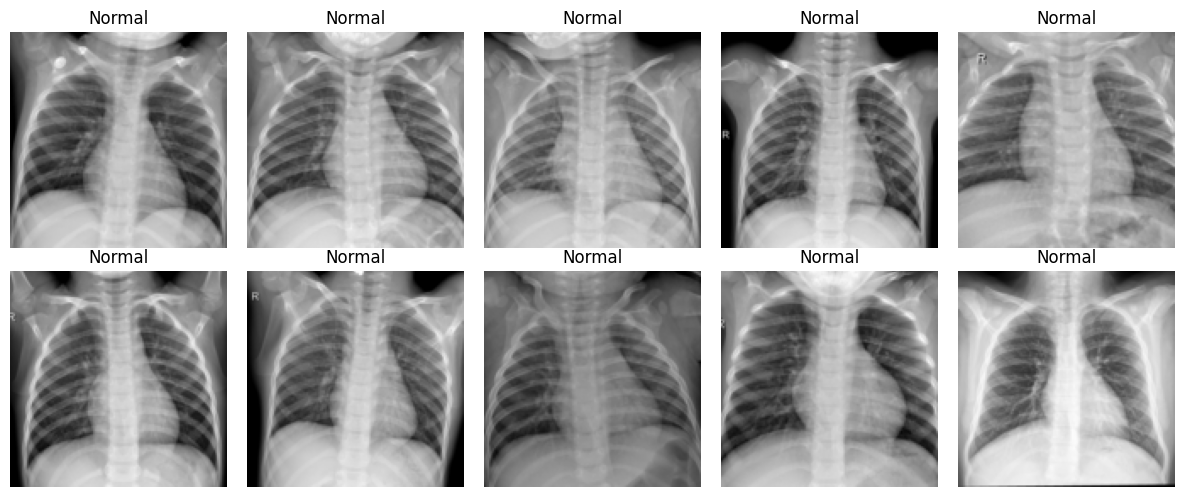

In [2]:
# Check whether the medmnist is installed 
try:
    import medmnist
    from medmnist import INFO
except ImportError:
    print("Installing medmnist...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "medmnist"])
    import medmnist
    from medmnist import INFO

# Load data from medmnist
def load_data(img_size=64, batch_size=128):
    """
    Downloads and prepares the PneumoniaMNIST data.
    Returns: train_loader, test_dataset, device
    """
    # Setup device for torch training. 
    # If the computer has a GPU setting up to use it else use CPU. 
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print(f"Using Apple (MPS) Acceleration")
    else:
        device = torch.device("cpu")
        print("Using CPU")

    print(f"Preparing Data (Size: {img_size}x{img_size})")

    # Define image transformation
    # Normalize to [-1, 1] for Diffusion Model which expect input centered at 0
    data_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[.5], std=[.5])
    ])

    # Download and initialize the dataset
    train_dataset = medmnist.PneumoniaMNIST(
        split='train', 
        transform=data_transform, 
        download=True, 
        size=img_size
    )
    
    test_dataset = medmnist.PneumoniaMNIST(
        split='test', 
        transform=data_transform, 
        download=True, 
        size=img_size
    )

    print("Filtering training data to ONLY include healthy lungs (Label 0)...")
    
    # Find the index of every image that has a label of 0 (Normal)
    healthy_indices = np.where(train_dataset.labels.squeeze() == 0)[0].tolist()
    
    # Create a new dataset using ONLY those healthy indices
    healthy_train_dataset = Subset(train_dataset, healthy_indices)

    # Create data loader for the train using the FILTERED dataset
    train_loader = DataLoader(
        dataset=healthy_train_dataset, # <--- Only healthy lungs for training
        batch_size=batch_size, 
        shuffle=True
    )
    
    # Verify that the training loader only contains label 0
    imgs, lbls = next(iter(train_loader))
    print("Sanity Check - Unique labels in training batch:", torch.unique(lbls))
    
    # Create data loader for the test (shuffle=False keeps labels aligned)
    test_loader = DataLoader(
        dataset=test_dataset, 
        batch_size=batch_size, 
        shuffle=False
    )

    print(f"Data Successfully Loaded! {len(healthy_train_dataset)} healthy training images, {len(test_dataset)} testing images.")
    return train_loader, test_loader, test_dataset, device

# -- Execution and verification --
IMG_SIZE = 128
BATCH_SIZE = 64

train_loader, test_loader, test_dataset, device = load_data(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

# -- Visualization --
print("\n Displaying Sample Images...")

# Take one batch
images, labels = next(iter(train_loader))

# -- Display images in same scale (Image Display Helper) --
# For visualization, we need to convert the normalized images back to [0, 1] range
def to_01(x):
    x = x.detach()
    if x.min() < 0:        # assume [-1,1] only when negatives exist
        x = (x + 1) / 2
    return x.clamp(0, 1)

# Function to display a single image in grayscale with proper scaling
def imshow_gray(x, title=None, show=True):
    x = x.detach().cpu()
    if x.dim() == 4: x = x[0]                 # [B,1,H,W] -> [1,H,W]
    if x.dim() == 3 and x.shape[0] == 1: x = x[0]  # [1,H,W] -> [H,W]
    x = to_01(x)
    plt.imshow(x, cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    if title: plt.title(title)
    if show: plt.show()

# Display the first 10 images in the batch with their labels
plt.figure(figsize=(12, 5))
for i in range(10):  # Show 10 images from the batch
    plt.subplot(2, 5, i+1)
    lbl = labels[i].item()
    
    imshow_gray(images[i], title="Pneumonia" if lbl == 1 else "Normal", show=False)
plt.tight_layout()
plt.show()

## U-Net Architecture
Defines the full **U-Net** model with three key components:
- `SinusoidalPositionEmbeddings` — encodes the timestep `t` into a continuous vector
- `Block` — a convolutional unit with **GroupNorm**, **SiLU** activation, and time conditioning
- `BetterUNet` — the full encoder–decoder with **skip connections**

Builds a fresh model instance and prints the total trainable parameter count.

In [3]:
# --- Define the U-Net Architecture ---
# Time embedding (Time --> Embedding vector)
class SinusoidalPositionEmbeddings(nn.Module):
    # Initialize neural network module with the size of embedding vector 'dim'
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2 # Build half embedding with Sin and other half with Cos
        embeddings = np.log(10000) / (half_dim - 1) # Setting the spacing of frequencies
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings) # Getting vector of decreasing frequencies
        embeddings = time[:, None] * embeddings[None, :] # Generating a vector for each sample t.ω 
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1) # Apply sin and cos for smooth periodic features
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=64):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1) # 2D Convolution layer, kernal is 3x3
        self.norm = nn.GroupNorm(8, out_ch) # GroupNorm stabilizes training
        self.act = nn.SiLU() # SiLU (Swish) activation function better for diffusion
        
        # Project time embeddings to match channel dimensions (B, time_emb_dim) --> (B, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t):
        h = self.conv(x)
        # Add time embedding (broadcast to image spatial dims)
        time_emb = self.act(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2] # Reshape time embedding to match spatial dimensions
        h = h + time_emb # Add time conditioning to every spatial location
        return self.act(self.norm(h))

class BetterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Time Embedding Block
        # Timestep turning into 64 dimensions vector
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(32),
            nn.Linear(32, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )

        # Encoder (Downsampling)
        self.conv0 = nn.Conv2d(1, 32, 3, padding=1) # Input channel is 1 (grayscale), output channel is 32, kernel size is 3x3, padding is 1
        self.down1 = Block(32, 64, 64)
        self.down2 = Block(64, 128, 64) # conv + add time embedding + norm + SiLU (Sigmoid Linear Unit - activation function)
        self.bot = Block(128, 256, 64) # Bottleneck (deepest part of the network)
        
        # Decoder (Upsampling)
        self.up1 = Block(256 + 128, 128, 64) # skip connections (add bottom + down2)
        self.up2 = Block(128 + 64, 64, 64) # skip connections (add up1 + down1)
        self.out = nn.Conv2d(64, 1, 1) # Output layer

    def forward(self, x, t):
        # Embed Time
        t = self.time_mlp(t) # Convert scalar timesteps into a vector embedding. Output shape becomes (B,64)
        
        # Downsample
        x0 = self.conv0(x) # First conv layer: Block(1→32)
        x1 = self.down1(x0, t)  # Block(32→64)
        x2 = self.down2(F.max_pool2d(x1, 2), t) # Max pooling with kernal size 2 and Block(64→128). x2: (B, 128, H/2, W/2)
        x3 = self.bot(F.max_pool2d(x2, 2), t) # (B, 128, H/4, W/4) bottom of the U net and smallest spacial size
        
        # Upsample & Skip Connections
        # Nearest Neighbor interpolation (simple and effective)
        x_up1 = F.interpolate(x3, scale_factor=2, mode='nearest') # Upscales spatial by 2 (H/4, W/4) → (H/2, W/2)
        x_up1 = torch.cat([x_up1, x2], dim=1) # Skip connection; concat encoder features x2 with decoder features x_up1 along channel dim 1
        x_up1 = self.up1(x_up1, t) # x_up1: (B, 128, H/2, W/2)

        x_up2 = F.interpolate(x_up1, scale_factor=2, mode='nearest') # second upscaling (H/2, W/2) → (H, W)
        x_up2 = torch.cat([x_up2, x1], dim=1) # x1: (B, 64, H, W), x_up2: (B, 128, H, W) -> concat x_up2: (B, 192, H, W)
        x_up2 = self.up2(x_up2, t) # Block(192→64)
        
        return self.out(x_up2) # Output layer --> Conv2d(64→1, kernel=1)

# --- Initialization Function ---

def initialize_model(device, learning_rate=1e-4):
    """
    Creates a fresh instance of the model and optimizer.
    Returns: model, optimizer
    """
    print(f"Building U-Net Model on {device}...")
    
    model = BetterUNet().to(device) # New instance of NN class
    
    # Check parameter count for identify model size
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model Parameters: {params:,}")
    
    # Use optimizer Adam: this will updates model weights during the training. learning rate 1e-4
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    return model, optimizer

# --- Execute ---
model, optimizer = initialize_model(device, learning_rate=1e-4)

Building U-Net Model on mps...
Model Parameters: 990,209


## Model Training
Sets the noise schedule constants (`β_start=0.0001`, `β_end=0.02`, `T=1000`) and trains the model for **50 epochs**. At each step:
1. A random timestep `t` and noise `ε ~ N(0,I)` are sampled
2. The image is corrupted via the closed-form forward process
3. The model predicts `ε` and the **MSE loss** is minimized

Saves trained weights to disk and plots the training loss curve.

Starting Training: 50 Epochs | Resolution: 128x128 | Device: mps


Epoch 1/50:   0%|          | 0/19 [00:00<?, ?it/s]

DEBUG: Image Range -> Min: -1.00, Max: 1.00


Loss: 0.0343: 100%|██████████| 19/19 [00:12<00:00,  1.46it/s]

Training Complete!
Model Saved to: ddpm_pneumonia_model_128x128.pth


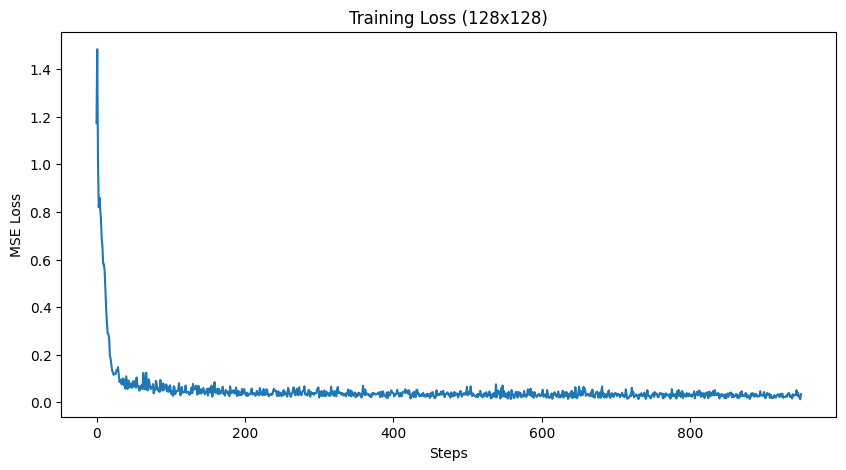

In [ ]:
# --- Global Diffusion Constants ---
BETA_START = 0.0001 # Starting noise level
BETA_END = 0.02 # End noise level
T_STEPS = 1000 # 1000 timesteps

def get_val(val_tensor, t, x_shape):
    """Helper to extract values from a tensor at specific time steps 't'. We need output shape like (B, 1, 1, 1)"""
    batch_t = t.long()
    out = val_tensor.gather(-1, batch_t).reshape(x_shape[0], *((1,) * (len(x_shape) - 1)))
    return out

# --- Training Function ---
def train_model(model, optimizer, train_loader, device, epochs=50, img_size=128):
    """
    Trains the Diffusion Model and saves the checkpoint.
    """
    print(f"Starting Training: {epochs} Epochs | Resolution: {img_size}x{img_size} | Device: {device}")
    
    # Pre-calculate Noise Schedule on the correct device
    betas = torch.linspace(BETA_START, BETA_END, T_STEPS).to(device) # Add noise variance at step t
    alphas = 1. - betas # Remain signals at step t
    alphas_cumprod = torch.cumprod(alphas, dim=0) # compute xt value

    model.train()
    losses = []

    # Training Loop
    for epoch in range(epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}") # Visualize progress for each epoch
        
        for batch_idx, batch in enumerate(pbar):
            # Load Data
            images = batch[0].to(device)
            
            # DEBUG: Sanity check on first batch of first epoch
            if epoch == 0 and batch_idx == 0:
                print(f"DEBUG: Image Range -> Min: {images.min().item():.2f}, Max: {images.max().item():.2f}")

            # Sample random time steps
            t = torch.randint(0, T_STEPS, (images.shape[0],), device=device)
            
            # Add Noise (Forward Diffusion Process)
            noise = torch.randn_like(images) # Gaussian noise N(0,1)
            sqrt_alpha_bar = get_val(torch.sqrt(alphas_cumprod), t, images.shape) # compute the each segments of the xt equation for each images's timesteps
            sqrt_one_minus_alpha_bar = get_val(torch.sqrt(1 - alphas_cumprod), t, images.shape)
            x_noisy = sqrt_alpha_bar * images + sqrt_one_minus_alpha_bar * noise
            
            # Predict Noise (Reverse Process)
            noise_pred = model(x_noisy, t)
            
            # Calculate Loss & Backprop
            loss = F.mse_loss(noise_pred, noise) # MSE (Mean Squared Error) between predicted noise and true noise
            
            optimizer.zero_grad() # Clear old gradients
            loss.backward() # Compute gradients of loss w.r.t all parameters
            optimizer.step() # Update weights using Adam
            
            losses.append(loss.item())
            pbar.set_description(f"Loss: {loss.item():.4f}") # Show the loss in progress

    print("Training Complete!")

    # Save Model
    save_path = f"weights/ddpm_pneumonia_model_{img_size}x{img_size}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Model Saved to: {save_path}")

    # Plot Loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title(f"Training Loss ({img_size}x{img_size})")
    plt.xlabel("Steps")
    plt.ylabel("MSE Loss")
    plt.show()
    
    return alphas_cumprod, betas # Return these as we need them for sampling later!

# --- Execute Training ---
alphas_cumprod, betas = train_model(model, optimizer, train_loader, device, epochs=50, img_size=IMG_SIZE)

## Load Pre-trained Model
> **Skip this cell if the model is already in memory from training.**

OR 
> **Run only this cell if you don't want to train the model again and again for later operations**

Loads saved model weights from `ddpm_pneumonia_model_128x128.pth` and reconstructs the diffusion schedules (`alphas_cumprod`, `betas`). Run this only after a kernel restart to avoid re-training from scratch.

In [29]:
# --- Constants (Must match training!) ---
BETA_START = 0.0001
BETA_END = 0.02
T_STEPS = 1000

def load_trained_model(device, img_size=64):
    """
    Loads a pre-trained model and recalculates diffusion schedules.
    Returns: model, alphas_cumprod, betas
    """
    print(f"Attempting to load saved model for {img_size}x{img_size}...")
    
    # 1. Re-calculate the Noise Schedule (Fast)
    betas = torch.linspace(BETA_START, BETA_END, T_STEPS).to(device)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    # 2. Initialize Empty Model
    model = BetterUNet().to(device)
    
    # 3. Load Weights
    filename = f"weights/ddpm_pneumonia_model_{img_size}x{img_size}.pth"
    
    if not os.path.exists(filename):
        print(f"Error: Model file '{filename}' not found!")
        print("You must run the TRAINING cell at least once to create this file.")
        return None, None, None
    
    # Load state dict
    try:
        model.load_state_dict(torch.load(filename, map_location=device))
        print(f"Successfully loaded '{filename}'!")
        print("You can now skip training and go straight to Image Generation.")
    except Exception as e:
        print(f"Error loading weights: {e}")
        print("The model architecture might have changed. Try retraining.")
        return None, None, None

    model.eval()
    return model, alphas_cumprod, betas

# --- EXECUTE LOADING ---
# Only run this if you want to SKIP training!
if 'alphas_cumprod' not in locals():
    # If variables don't exist yet (e.g., fresh restart), try loading
    model, alphas_cumprod, betas = load_trained_model(device, img_size=IMG_SIZE)
else:
    print("Model and schedules already loaded in memory.")

Model and schedules already loaded in memory.


## DDPM Sampling
Generates new synthetic chest X-rays by running the full **DDPM reverse process** — starting from pure Gaussian noise `x_T ~ N(0,I)` and iteratively denoising over `T=1000` steps. Displays:
- The **final generated images**
- A **denoising strip** showing the image progressively forming from noise

No sampled results found. Running DDPM sampling now...
Generating 5 X-Rays from pure noise...


Denoising: 100%|██████████| 1000/1000 [00:18<00:00, 53.26it/s]



--- Final Generated Images ---


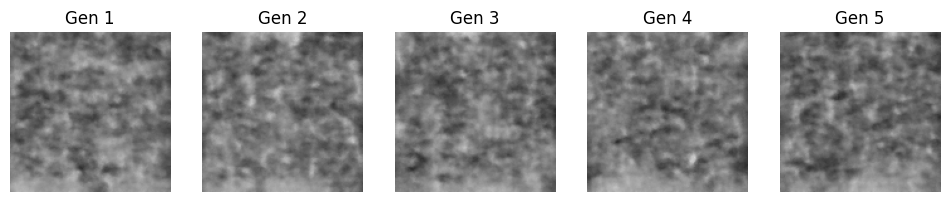


--- The Denoising Process (Noise -> Organ) ---


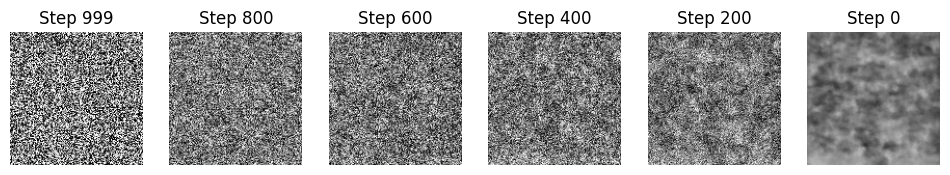

In [5]:
# --- Modular Sampling Function ---

@torch.no_grad() # Update PyTorch to not to compute gradients as this is not trainign process

def generate_samples(model, device, alphas_cumprod, betas, n_samples=5, img_size=128, t_steps=1000):
    """
    Generates new images from pure noise using the trained model.
    """
    model.eval()
    print(f"Generating {n_samples} X-Rays from pure noise...")
    
    # Start with pure random noise (x_T)
    x = torch.randn(n_samples, 1, img_size, img_size).to(device)
    
    # Pre-calculate alphas for the specific formula
    # Move calculations to the correct device to ensure all tensors are on the same device (CPU or GPU)
    betas = betas.to(device)
    alphas_cumprod = alphas_cumprod.to(device)

    alphas = 1.0 - betas
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    
    # Store snapshots to visualize the "healing" process
    snapshots = []
    
    # Iterate backwards from T to 0
    for i in tqdm(reversed(range(t_steps)), desc="Denoising", total=t_steps):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        
        # Predict noise
        predicted_noise = model(x, t)
        
        # Get diffusion parameters for this step
        alpha = alphas[i]
        alpha_cumprod = alphas_cumprod[i]
        beta = betas[i]
        
        # Recover image (Standard DDPM Formula)
        # Inject Gaussian noise at each step except the last step
        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x) # No noise added at the final step
            
        # Remove predicted noise and add a tiny bit of Langevin noise (DDPM reverse update)
        # Calculate the mean
        mean = (1.0 / torch.sqrt(alpha)) * (x - ((1.0 - alpha) / torch.sqrt(1.0 - alpha_cumprod)) * predicted_noise)
        
        # Calculate the variance
        sigma = torch.sqrt(posterior_variance[i])

        # Combine mean and variance to get the healed image
        x = mean + sigma * noise # Add randomness (stochasticity) 
        
        # Stability Clamp (keep the sample stable and prevent out of range intensity spickes)
        x = torch.clamp(x, -1.0, 1.0)
        
        # Save snapshots at specific milestones (Start, 75%, 50%, 25%, End)
        if i % (t_steps // 5) == 0 or i == 0 or i == t_steps - 1:
            snapshots.append((i, x[0].detach().cpu().clone()))

    return x, snapshots

def plot_sampling_process(x,snapshots):
    """
    Plots the sampling process snapshots.
    """
    n_samples = x.size(0)
    plt.figure(figsize=(12, 4))
    print("\n--- Final Generated Images ---")
    for k in range(n_samples):
        plt.subplot(1, n_samples, k+1)
        imshow_gray(x[k], title=f"Gen {k+1}", show=False)
    plt.show()

    # Show Denoising Process (Animation Strip)
    plt.figure(figsize=(12, 3))
    print("\n--- The Denoising Process (Noise -> Organ) ---")
    num_snaps = len(snapshots)
    for k, (t_i,snap) in enumerate(snapshots):
        plt.subplot(1, num_snaps, k+1)
        imshow_gray(snap, title=f"Step {t_i}", show=False)
    plt.show()

try:
    x_final
    snapshots
    print("Using existing sampled results (no re-sampling).")
except NameError:
    print("No sampled results found. Running DDPM sampling now...")
    # Note: We use 'alphas_cumprod' and 'betas' returned from the training cell!
    x_final, snapshots = generate_samples(model, device, alphas_cumprod, betas, n_samples=5, img_size=IMG_SIZE)
plot_sampling_process(x_final, snapshots)

## DDPM Anomaly Detection (Single Image)
Demonstrates the anomaly detection pipeline on a **single pneumonia image**. Corrupts it to `t_start=150`, heals it using the model, then plots four panels:

| Panel | Description |
|---|---|
| Original | The real pneumonia X-ray |
| Corrupted | After adding noise up to `t_start` |
| Healed | Model-reconstructed "healthy" version |
| Anomaly Map | `\|original − healed\|` — bright regions indicate infection |

Searching for Pneumonia case #4 in Test Set...
Loaded Pneumonia X-Ray (Test Index 5)
Corrupting and Healing from step 150...


Healing: 100%|██████████| 150/150 [00:01<00:00, 108.12it/s]


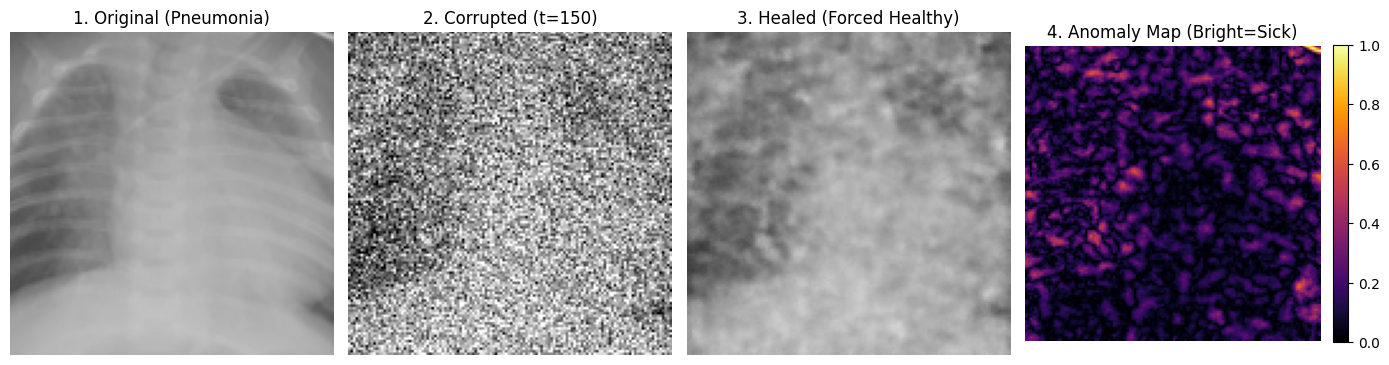

In [6]:
# --- Anomaly Detection Function ---

from matplotlib.pylab import diff


@torch.no_grad()
def detect_anomalies(model, device, test_dataset, alphas_cumprod, betas, img_size=128, t_start=400, sample_index=0, diff_threshold=0.15):
    """
    Takes a Pneumonia image, adds noise, and lets the model 'heal' it to detect anomalies.
    """
    model.eval()
    print(f"Searching for Pneumonia case #{sample_index + 1} in Test Set...")
    
    # --- Ensure schedules are on the correct device ---
    betas = betas.to(device)
    alphas_cumprod = alphas_cumprod.to(device)

    # Precompute alphas and posterior variance (DDPM correct noise scale)
    alphas = 1.0 - betas
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

    # Find a Pneumonia Image (Class 1)
    target_img = None
    pneumonia_count = 0
    found_test_index = None
    
    # Loop through the test dataset to find the specific pneumonia case
    for idx in range(len(test_dataset)):
        img, label = test_dataset[idx]
        # MedMNIST labels are arrays like [1], so we use .item() to get the integer
        if label.item() == 1: 
            if pneumonia_count == sample_index:
                target_img = img.unsqueeze(0).to(device) # Add batch dim -> [1, 1, 128, 128]
                found_test_index = idx
                break
            pneumonia_count += 1
            
    if target_img is None:
        print("Could not find a Pneumonia image at that index.")
        return

    print(f"Loaded Pneumonia X-Ray (Test Index {found_test_index})")
    print(f"Corrupting and Healing from step {t_start}...")

    # Corrupt the image (Forward Diffusion to t_start)
    # Forward process: q(x_t | x_0) to jump directly to step t_start
    noise = torch.randn_like(target_img)
    alpha_bar_t = alphas_cumprod[t_start]  # already on device
    noisy_img = torch.sqrt(alpha_bar_t) * target_img + torch.sqrt(1.0 - alpha_bar_t) * noise

    # Reverse process: p(x_{t-1} | x_t) to heal the image back to step 0
    curr_img = noisy_img.clone()
    
    # Pre-calculate alphas for the reverse step
    alphas = 1.0 - betas

    for j in tqdm(reversed(range(0, t_start)), desc="Healing", total=t_start):
        t_tensor = torch.full((1,), j, device=device, dtype=torch.long)
        
        # Predict noise epsilon
        eps_pred = model(curr_img, t_tensor)
        
        # Params
        alpha_t = alphas[j]
        alpha_bar_t = alphas_cumprod[j]
        
        # DDPM mean (epsilon-parameteriation)
        mean = (1.0 / torch.sqrt(alpha_t)) * (curr_img - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred)
        
        # Recover image
        if j > 0:
            z = torch.randn_like(curr_img)
        else:
            z = torch.zeros_like(curr_img)
            
        # DDPM Sampling Step
        sigma = torch.sqrt(posterior_variance[j])
        curr_img = mean + sigma * z
        
        # Stability Clamp
        curr_img = torch.clamp(curr_img, -1.0, 1.0)
    
    # Calculate Difference (Anomaly Map) 
    original = target_img.detach().cpu().squeeze().numpy() 
    healed = curr_img.detach().cpu().squeeze().numpy()
    
    # Absolute difference tells us what changed
    diff = np.abs(original - healed)
    diff_norm = (diff/ (diff.max() + 1e-8)) # Normalize to [0, 1]
    # Apply a small threshold to remove random background noise (only for visualization, not for actual detection)
    # This makes the infection spots pop out more clearly
    diff_vis = diff.copy()
    diff_vis[diff_vis<diff_threshold] = 0.0 
    
    # Visualization
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 4, 1)
    imshow_gray(target_img, title="1. Original (Pneumonia)", show=False)
    
    plt.subplot(1, 4, 2)
    imshow_gray(noisy_img, title=f"2. Corrupted (t={t_start})", show=False)

    plt.subplot(1, 4, 3)
    imshow_gray(curr_img, title="3. Healed (Forced Healthy)", show=False)

    plt.subplot(1, 4, 4)
    plt.title("4. Anomaly Map (Bright=Sick)")
    plt.imshow(diff_norm, cmap='inferno', vmin=0, vmax=1.0) 
    plt.colorbar(fraction=0.046, pad=0.04) 
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return original, healed, diff

# --- EXECUTE DETECTION ---
# We use the variables 'alphas_cumprod' and 'betas' from your training/loading cell
original, healed, diff = detect_anomalies(model, device, test_dataset, alphas_cumprod, betas, img_size=IMG_SIZE, t_start=150, sample_index=3, diff_threshold=0.15)


## DDPM Score Caching
Runs the full anomaly scoring pipeline over the **entire test set** using DDPM reconstruction at `t_start=400`. Computes and saves two types of anomaly scores to `cached_scores_ddpm_t400_multi_topk_updated.npz`:
- **Mean score** — average pixel-wise reconstruction error
- **Top-K scores** — mean error of the top `0.5%, 1%, 2%, 5%` highest-error pixels

> Scores are cached to disk to avoid re-running slow reverse diffusion during evaluation.

In [ ]:
# === CACHING ANOMALY SCORES (MEAN + MULTIPLE TOP-K METHODS) ===

CACHE_PATH = "cache/cached_scores_ddpm_t400_multi_topk_updated.npz"

# Use the same t_start as before for consistency in the level of corruption (anomaly) we are testing against.
# Higher values mean stronger corruption before healing
t_start = 400

# TOP-K ratios for anomaly scoring
# Example: 0.01 means top 1% pixels with highest reconstruction error
TOPK_RATIOS = [0.005, 0.01, 0.02, 0.05]  # 0.5%, 1%, 2%, 5%

true_labels = []
scores_mean = []
scores_topk = {r: [] for r in TOPK_RATIOS}

model.eval()

betas_d = betas.to(device)
alphas_cumprod_d = alphas_cumprod.to(device)

# Precompute diffusion parameters used during reverse sampling
alphas = 1.0 - betas_d
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod_d[:-1]])

# Posterior variance used in DDPM reverse step
posterior_variance = betas_d * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod_d)

print(f"Running the evaluation and saving scores to {CACHE_PATH}")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Caching scores"):
        images = images.to(device)

        # --- Forward diffusion: add noise up to t_start ---
        # Instead of applying noise step-by-step, we directly
        # sample x_t using the closed-form formula q(x_t | x_0)
        noise = torch.randn_like(images)
        alpha_bar_t = alphas_cumprod_d[t_start]
        noisy = torch.sqrt(alpha_bar_t) * images + torch.sqrt(1.0 - alpha_bar_t) * noise

        # --- Reverse diffusion: reconstruct the image from x_t back to x_0 ---
        x = noisy.clone()
        for i in reversed(range(0, t_start)):
            
            t_step = torch.full((images.size(0),), i, device=device, dtype=torch.long)
            
            # Model predicts the noise ε
            eps_pred = model(x, t_step)

            alpha_t = alphas[i]
            alpha_bar = alphas_cumprod_d[i]

            # DDPM mean reconstruction formula
            mean = (1.0 / torch.sqrt(alpha_t)) * (
                x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar)) * eps_pred
            )

            z = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
            sigma = torch.sqrt(posterior_variance[i])
            x = torch.clamp(mean + sigma * z, -1.0, 1.0)

        # —-- Compute reconstruction error (anomaly score) ---
        # The anomaly score is based on the difference between:
        # original image and reconstructed ("healed") image
        diff = torch.abs(images - x)

        flat = diff.view(images.size(0), -1)

        # ---- Mean anomaly score (average pixel-wise error) ----
        mean_score = -flat.mean(dim=1)  # Average error per pixel (unmasked)
        
        # Store labels from the test set (0 for Normal, 1 for Pneumonia)
        labels_np = labels.squeeze().cpu().numpy().astype(int)
        true_labels.extend(labels_np.tolist())
        
        # Store mean scores
        scores_mean.extend(mean_score.cpu().numpy().tolist())

        # ---- TOP-K anomaly scores ----
        # Pneumonia usually appears as localized infection spots. 
        # Instead of averaging all pixels, we focus on the pixels with the highest reconstruction errors.
        for r in TOPK_RATIOS:
            k = max(1, int(r * flat.size(1)))
            topk_vals, _ = torch.topk(flat, k=k, dim=1)
            scores_topk[r].extend((-topk_vals.mean(dim=1)).cpu().numpy().tolist())

# Save all arrays into one file
save_dict = {
    "y": np.array(true_labels, dtype=np.int64),
    "mean": np.array(scores_mean, dtype=np.float32),
    "t_start": np.array([t_start]),
    "topk_ratios": np.array(TOPK_RATIOS, dtype=np.float32),
}
for r in TOPK_RATIOS:
    key = f"topk_{str(r).replace('.','p')}"   # e.g., topk_0p01
    save_dict[key] = np.array(scores_topk[r], dtype=np.float32)

np.savez(CACHE_PATH, **save_dict)
print("Saved multi-topk cached scores successfully")

Running the evaluation and saving scores to cached_scores_ddpm_t400_multi_topk_updated.npz


Caching scores: 100%|██████████| 10/10 [15:30<00:00, 93.01s/it]

Saved multi-topk cached scores successfully


## DDPM Evaluation
Loads the cached DDPM scores and evaluates all scoring methods. Produces:
- **ROC (Receiver Operating Characteristic) curves** with AUROC for each scoring method
- **Confusion matrices** at a fixed **95% specificity** target, reporting sensitivity and accuracy

The best-performing method is selected automatically by highest AUROC.

Keys in cache: ['mean', 't_start', 'topk_0p005', 'topk_0p01', 'topk_0p02', 'topk_0p05', 'topk_ratios', 'y']

Evaluation Summary:
  Method          AUROC    AUPRC
  ------------------------------
  MEAN           0.7599   0.8373
  TOP-0.50%      0.8409   0.8987
  TOP-1.00%      0.8458   0.9010
  TOP-2.00%      0.8482   0.9014
  TOP-5.00%      0.8461   0.8993
  ------------------------------
  Best           0.8482   0.9014  <- TOP-2.00%


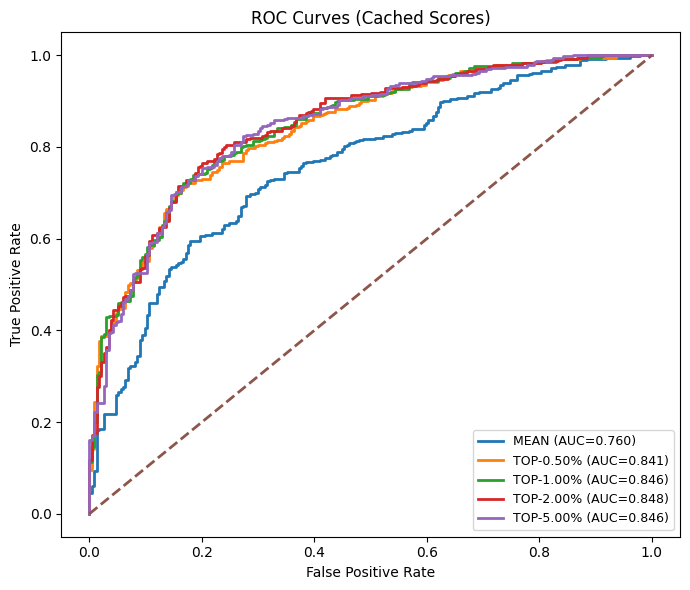

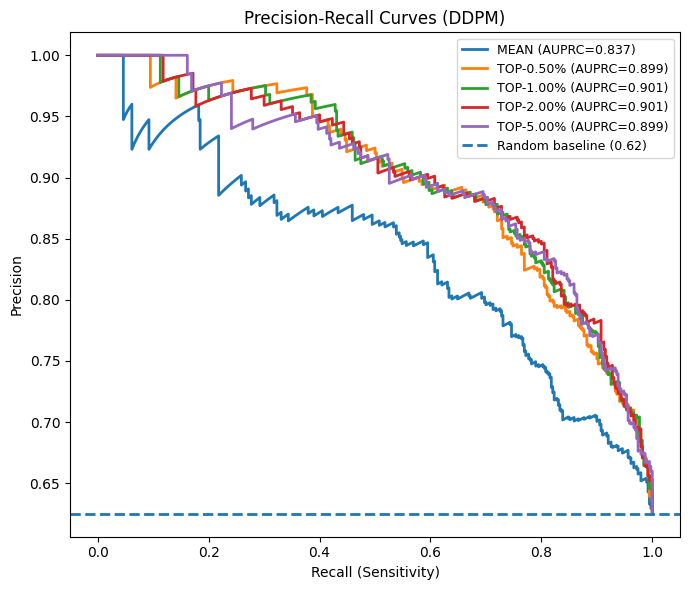


--- MEAN @ 95% Specificity ---
  Threshold  : -0.2067
  Sensitivity: 0.259  (Recall — sick cases caught)
  Specificity: 0.953  (healthy cases correctly cleared)
  Precision  : 0.902  (of flagged, how many truly sick)
  F1 Score   : 0.402
  Accuracy   : 0.519


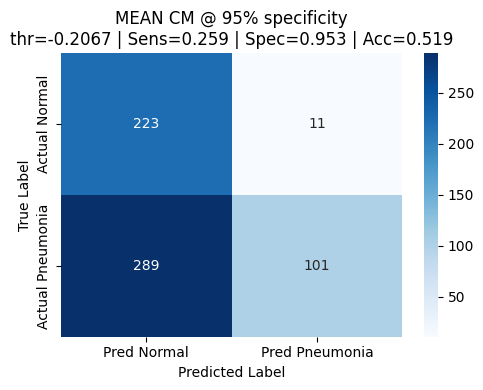


--- TOP-2.00% @ 95% Specificity ---
  Threshold  : -0.6461
  Sensitivity: 0.444  (Recall — sick cases caught)
  Specificity: 0.953  (healthy cases correctly cleared)
  Precision  : 0.940  (of flagged, how many truly sick)
  F1 Score   : 0.603
  Accuracy   : 0.635


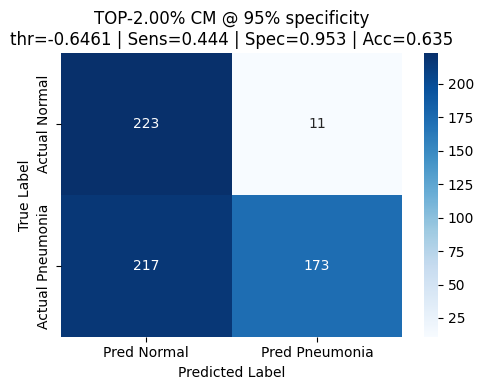

In [27]:
# === LOADING CACHED SCORES + FINAL EVALUATION REPORT ===

CACHE_PATH = "cached_scores_ddpm_t400_multi_topk_updated.npz"

# Choose specificity target for threshold selection (95% = strict on false positives)
TARGET_SPEC = 0.95

# Load cached arrays
data = np.load(CACHE_PATH, allow_pickle=True)
print("Keys in cache:", sorted(data.files))

# True labels for each test image (0=normal, 1=pneumonia)
y = data["y"].astype(int)
n = len(y) # number of test samples

# Choose threshold based on target specificity
# We compute ROC curve thresholds, then select the threshold that gives
# specificity closest to TARGET_SPEC.
def threshold_at_specificity(y, scores, target_spec=0.95):
    fpr, tpr, thr = roc_curve(y, scores)
    
    # Filter out any infinite thresholds (can happen if there are duplicate scores)
    finite = np.isfinite(thr)
    fpr_f, thr_f = fpr[finite], thr[finite]
    spec_f = 1 - fpr_f
    
    # Pick threshold whose specificity is closest to desired target
    idx = np.argmin(np.abs(spec_f - target_spec))
    return thr_f[idx]

# -- Confusion matrix + metrics --
def cm_and_metrics(y, scores, thr):
    pred = (scores > thr).astype(int)
    cm = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    spec      = tn / (tn + fp + 1e-12)
    sens      = tp / (tp + fn + 1e-12)
    acc       = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    f1        = 2 * (precision * sens) / (precision + sens + 1e-12)
    return cm, sens, spec, acc, precision, f1

# --- Collect methods safely ----
methods = {}

# 1 - MEAN
mean_scores = data["mean"].astype(np.float32)

# Sanity check
if len(mean_scores) != n:
    raise ValueError(f"'mean' length {len(mean_scores)} != y length {n}")
methods["MEAN"] =  mean_scores

# 2 - TOP-K score arrays
# Filter only keys starting with "topk_" and length == n (per-image scores)
topk_keys = sorted([k for k in data.files if k.startswith("topk_")])

kept = [] # topk arrays used in evaluation
skipped = [] # keys that are not per-image scores (metadata arrays etc.)

for k in topk_keys:
    arr = data[k]

    # Skip non 1D arrays OR arrays that do not match dataset length
    if arr.ndim != 1 or len(arr) != n:
        skipped.append((k, arr.shape))
        continue

    # Create readable label from key name (e.g., topk_0p01 -> TOP-1.00%)
    raw = k.replace("topk_", "").replace("p", ".")
    try:
        ratio = float(raw)
        label = f"TOP-{ratio*100:.2f}%"
    except:
        label = k

    methods[label] = arr.astype(np.float32)
    kept.append((k, label))

# --- AUROC + AUPRC Summary Table ---
print("\nEvaluation Summary:")
print(f"  {'Method':<12} {'AUROC':>8} {'AUPRC':>8}")
print(f"  {'-'*30}")

summary = []
for name, scores in methods.items():
    auroc = roc_auc_score(y, scores)
    auprc = average_precision_score(y, scores)
    summary.append((name, auroc, auprc))
    print(f"  {name:<12} {auroc:>8.4f} {auprc:>8.4f}")

print(f"  {'-'*30}")
best_overall = max(summary, key=lambda x: (x[1] + x[2]) / 2)
print(f"  {'Best':<12} {best_overall[1]:>8.4f} {best_overall[2]:>8.4f}  <- {best_overall[0]}")

best_name = best_overall[0]

# --- ROC plot ---
plt.figure(figsize=(7, 6))
for name, scores in methods.items():
    fpr, tpr, _ = roc_curve(y, scores)
    au = roc_auc_score(y, scores)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={au:.3f})")

# diagonal baseline = random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Cached Scores)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# --- Precision-Recall Curves (DDPM) ---
plt.figure(figsize=(7, 6))
for name, scores in methods.items():
    prec, rec, _ = precision_recall_curve(y, scores)
    auprc = average_precision_score(y, scores)
    plt.plot(rec, prec, lw=2, label=f"{name} (AUPRC={auprc:.3f})")

# Baseline = random classifier at the positive class ratio
baseline = y.sum() / len(y)
plt.axhline(baseline, linestyle="--", lw=2, label=f"Random baseline ({baseline:.2f})")

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (DDPM)")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# --- Confusion matrices: MEAN + BEST ---
def plot_cm(name):
    scores = methods[name]
    
    # Choose threshold so that specificity is ~TARGET_SPEC
    thr = threshold_at_specificity(y, scores, target_spec=TARGET_SPEC)

     # Compute confusion matrix + metrics
    cm, sens, spec, acc, precision, f1 = cm_and_metrics(y, scores, thr)
    
    # Print full metrics report
    print(f"\n--- {name} @ {TARGET_SPEC*100:.0f}% Specificity ---")
    print(f"  Threshold  : {thr:.4f}")
    print(f"  Sensitivity: {sens:.3f}  (Recall — sick cases caught)")
    print(f"  Specificity: {spec:.3f}  (healthy cases correctly cleared)")
    print(f"  Precision  : {precision:.3f}  (of flagged, how many truly sick)")
    print(f"  F1 Score   : {f1:.3f}")
    print(f"  Accuracy   : {acc:.3f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred Normal", "Pred Pneumonia"],
        yticklabels=["Actual Normal", "Actual Pneumonia"]
    )
    plt.title(
        f"{name} CM @ {TARGET_SPEC*100:.0f}% specificity\n"
        f"thr={thr:.4f} | Sens={sens:.3f} | Spec={spec:.3f} | Acc={acc:.3f}"
    )
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

plot_cm("MEAN")
if best_name != "MEAN":
    plot_cm(best_name)

## DDIM Sampling
Implements **DDIM sampling** using a fixed evenly-spaced timestep schedule between `1` and `T`. Unlike DDPM, DDIM is **deterministic** (`η=0`) — the same noise input always produces the same image. Key parameters:
- `ddim_steps` — number of reverse steps (far fewer than DDPM's 1000)
- `eta` — stochasticity factor (`0.0` = fully deterministic, `1.0` = DDPM-like)
- `clamp_x0`, `clamp_x` — stability clamping to prevent pixel value blow-up

DDIM-fixed (steps=999, eta=0.0): 100%|██████████| 999/999 [00:30<00:00, 32.45it/s]


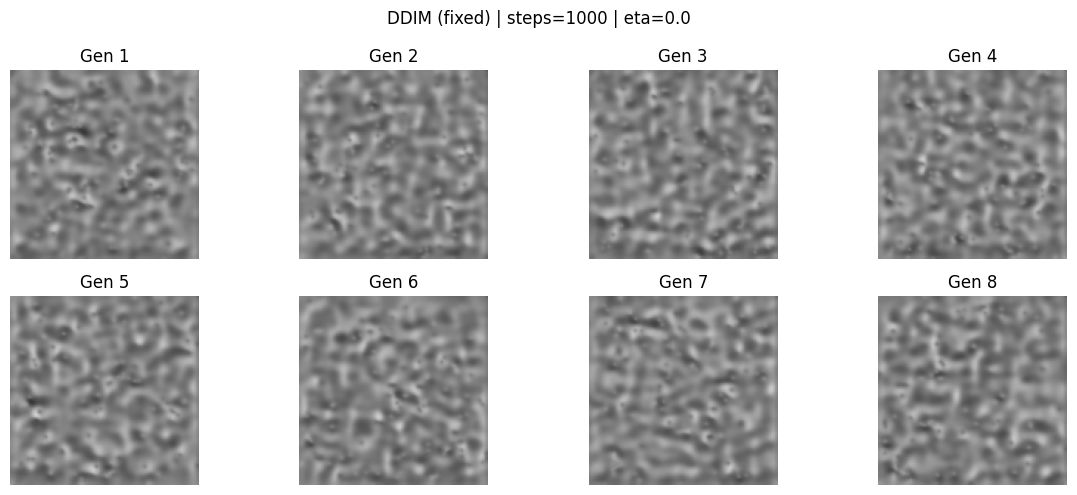

In [5]:
def show_batch_gray(images, labels=None, n_show=10, ncols=5, title=None, figsize=(12, 5), prefix="Sample"):
    """
    Show a batch/grid of grayscale images using imshow_gray() for consistent [0,1] display.
    """
    if not isinstance(images, torch.Tensor):
        raise ValueError("images must be a torch.Tensor")
    
    # Move to CPU and detach from graph for visualization
    x = images.detach().cpu()

    # Convert [N,1,H,W] -> [N,H,W]
    if x.dim() == 4 and x.size(1) == 1:
        x = x[:, 0]
    elif x.dim() != 3:
        raise ValueError(f"Expected [N,1,H,W] or [N,H,W], got {tuple(images.shape)}")

    n = min(n_show, x.size(0))
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=figsize)
    if title:
        plt.suptitle(title)

    for i in range(n):
        plt.subplot(nrows, ncols, i + 1)

        # Decide subplot title
        t = None
        if labels is not None:
            lbl = labels[i]
            if isinstance(lbl, torch.Tensor):
                lbl = lbl.item()
            t = "Pneumonia" if int(lbl) == 1 else "Normal"
        else:
            t = f"{prefix} {i+1}"

        imshow_gray(x[i], title=t, show=False)

    plt.tight_layout()
    plt.show()

def make_ddim_timesteps_1_to_T(T=1000, ddim_steps=50, device="cpu"):
    # timesteps in [1..T]
    idx = torch.linspace(1, T, steps=ddim_steps, device=device).round().long() # Generate 'ddim_steps' evenly spaced integers between 1 and T (inclusive)
    idx[0] = 1
    idx[-1] = T
    idx = torch.unique(idx)
    return idx

@torch.no_grad()
def generate_samples_ddim_fixed(
    model, device, alphas_cumprod, n_samples=8, img_size=64,
    T=1000, ddim_steps=50, eta=0.0, clamp_x0=False, clamp_x=True
):
    """
    DDIM sampling with alpha_bar extended to include alpha_bar[0]=1.
    Model is called with timestep (t-1) in [0..T-1] to match training.
    """
    model.eval()

    # extend alpha_bar: [1.0, alpha_bar_1, ..., alpha_bar_T]
    alpha_bar = alphas_cumprod.to(device)
    alpha_bar = torch.cat([torch.ones(1, device=device), alpha_bar], dim=0)  # length T+1

    # timesteps and reverse
    ts = make_ddim_timesteps_1_to_T(T=T, ddim_steps=ddim_steps, device=device)
    ts_rev = list(reversed(ts.tolist()))

    # start from x_T ~ N(0,1), which is pure noise
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)

    for j in tqdm(range(len(ts_rev) - 1), desc=f"DDIM-fixed (steps={len(ts_rev)-1}, eta={eta})"):
        t = ts_rev[j]       # in [1..T]
        t_prev = ts_rev[j+1]  # next (smaller) timestep, moving toward t=1 (less noise)

        # model timestep should be [0..T-1]
        t_model = torch.full((n_samples,), t - 1, device=device, dtype=torch.long)
        
        # Pre-calculate alpha_bar values for current and previous timesteps
        a_t = alpha_bar[t]
        a_prev = alpha_bar[t_prev]
        
        # Predict noise using the model (This is the ε-prediction network output what the model was trained to predict) 
        eps = model(x, t_model)
        
        # Estimate clean image x0 from the predicted noise and current noisy image x
        x0 = (x - torch.sqrt(1.0 - a_t) * eps) / torch.sqrt(a_t)

        # To prevent extreme pixel values dufing sampling, we can optionally clamp x0 to [-1, 1] in order to keep the gnerated image stable.
        # This help to prevent out of range pixels which can cause artifacts
        if clamp_x0:
            x0 = torch.clamp(x0, -1.0, 1.0)

        # Compute the direction pointing to x_t (the "noise" component) and the variance term (sigma) for the update step
        # The sigma term controls the amount of randomness injected at each step. Setting eta=0 means no randomness (deterministic), while eta=1 means full randomness as in DDPM.
        sigma = eta * torch.sqrt((1 - a_prev) / (1 - a_t) * (1 - a_t / a_prev))

        dir_xt = torch.sqrt(torch.clamp(1.0 - a_prev - sigma**2, min=0.0)) * eps

        noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)
        x = torch.sqrt(a_prev) * x0 + dir_xt + sigma * noise
        
        # Stability clamp to keep pixel values in a reasonable range during sampling. This may over smooth the image but can prevent extreme artifacts.
        if clamp_x:
            x = torch.clamp(x, -1.0, 1.0)

    return x

# ---- Run DDIM sampling & show output ----
N_SAMPLES = 8
DDIM_STEPS = 1000
ETA = 0.0

samples_ddim = generate_samples_ddim_fixed(
    model=model,
    device=device,
    alphas_cumprod=alphas_cumprod,
    n_samples=N_SAMPLES,
    img_size=IMG_SIZE,
    T=1000,
    ddim_steps=DDIM_STEPS,
    eta=ETA,
    clamp_x0=True,
    clamp_x =True
)

show_batch_gray(samples_ddim, ncols=4, title=f"DDIM (fixed) | steps={DDIM_STEPS} | eta={ETA}", prefix="Gen")

## DDIM Reconstruction
Core building block for **DDIM-based anomaly detection**. Given a clean image `x_0`:
1. Adds noise up to `t_start` using the closed-form forward process
2. Runs the **deterministic DDIM reverse** back to `t=0`
3. Returns the reconstructed `x_0_pred` — the model's "healthy" version of the input

Used by the scoring pipeline in the next cell.

In [13]:
@torch.no_grad()
def ddim_reconstruct_from_tstart(model, x0, alphas_cumprod, t_start=400, ddim_steps=50, eta=0.0, device="cpu"):
    """
    x0: clean image tensor in [-1,1], shape [B,1,H,W]
    returns: recon tensor (approx x at t=0), shape [B,1,H,W]
    """
    
    model.eval()
    B = x0.size(0) # batch size. Use this to create the correct shape for the timestep tensor when calling the model.

    # alpha_bar extended: [1, alpha_bar_1..alpha_bar_T] : length T+1, where alpha_bar[0]=1.
    alpha_bar = alphas_cumprod.to(device)
    alpha_bar = torch.cat([torch.ones(1, device=device), alpha_bar], dim=0)

    # Choosing DDIM timesteps in [1..t_start]
    # Use the same make_ddim_timesteps function.
    ts = make_ddim_timesteps_1_to_T(T=t_start, ddim_steps=ddim_steps, device=device) 
    ts_rev = list(reversed(ts.tolist())) # Reverse the timesteps to go from t_start down to 1 (healing process)

    # Forward diffusion to create x_{t_start}
    a_start = alpha_bar[t_start]
    noise = torch.randn_like(x0) # Sample ε ~ N(0,1).
    x = torch.sqrt(a_start) * x0 + torch.sqrt(1 - a_start) * noise 

    # Reverse DDIM (the reconstruction process)
    for j in range(len(ts_rev) - 1):
        t = ts_rev[j]
        t_prev = ts_rev[j + 1]

        # model expects [0..999], so use (t-1)
        t_model = torch.full((B,), t - 1, device=device, dtype=torch.long)

        # Pre-calculate alpha_bar values for current and previous timesteps
        a_t = alpha_bar[t]
        a_prev = alpha_bar[t_prev]
        
        # Predict noise ε using the model
        eps = model(x, t_model)

        x0_pred = (x - torch.sqrt(1 - a_t) * eps) / torch.sqrt(a_t)
        x0_pred = torch.clamp(x0_pred, -1, 1) # Clamp to keep the predicted clean image stable during reconstruction

        # if eta=0 => sigma=0 => deterministic DDIM, no noise added during sampling
        sigma = eta * torch.sqrt((1 - a_prev) / (1 - a_t) * (1 - a_t / a_prev))
        dir_xt = torch.sqrt(torch.clamp(1 - a_prev - sigma**2, min=0.0)) * eps
        
        z = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)

        x = torch.sqrt(a_prev) * x0_pred + dir_xt + sigma * z

    # Final best estimate of the original image after reconstruction process
    return x0_pred

## DDIM Score Caching + Evaluation
Runs `ddim_reconstruct_from_tstart()` over the **full test set** and caches mean + Top-K anomaly scores to disk. Then loads and evaluates them — plotting **ROC curves** and **confusion matrices** at 95% specificity, mirroring the full DDPM evaluation. Automatically checks and corrects score direction to ensure higher score = more likely pneumonia.

Loading cached scores from cache/cached_scores_ddim_t400_s100_eta0_multi_topk_updated.npz
Keys in cache: ['ddim_steps', 'eta', 'mean_scores', 'store_fliped', 't_start', 'topk_0p005', 'topk_0p01', 'topk_0p02', 'topk_0p05', 'topk_ratios', 'y']
Methods included: ['MEAN', 'TOPK_0P005', 'TOPK_0P01', 'TOPK_0P02', 'TOPK_0P05']

Evaluation Summary:
  Method            AUROC    AUPRC
  --------------------------------
  MEAN             0.8481   0.9001
  TOPK_0P005       0.7924   0.8673
  TOPK_0P01        0.8073   0.8771
  TOPK_0P02        0.8196   0.8853
  TOPK_0P05        0.8348   0.8942
  --------------------------------
  Best             0.8481   0.9001  <- MEAN


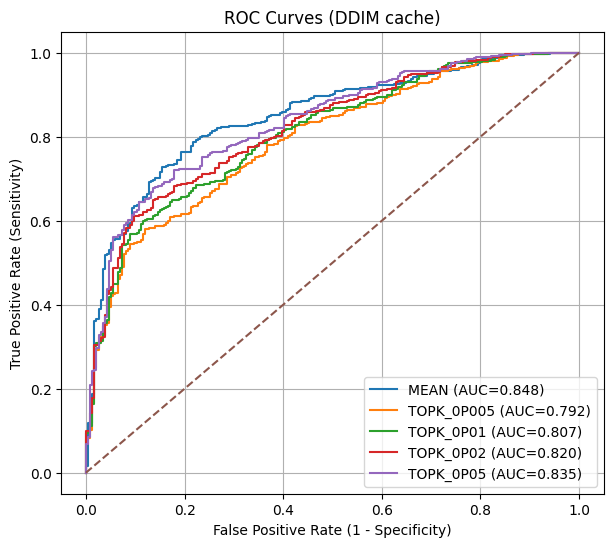

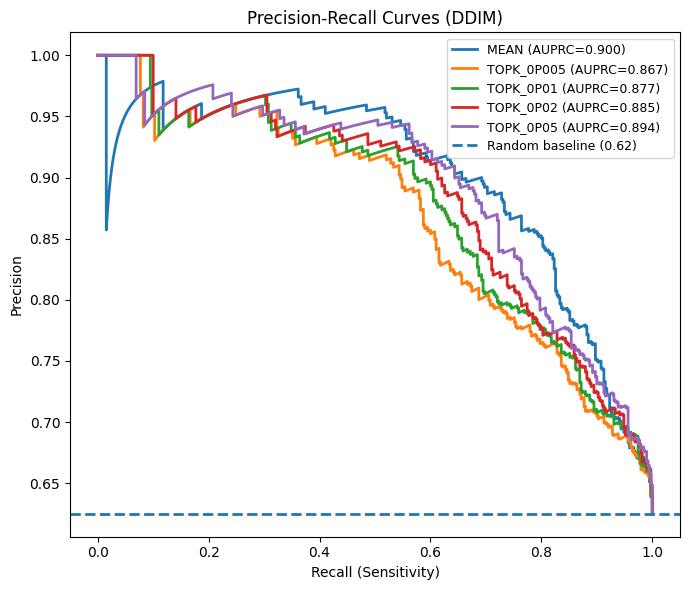


Best method by AUROC: MEAN AUC= 0.8481262327416174

--- MEAN @ 95% Specificity ---
  Threshold  : -0.138840
  Sensitivity: 0.531  (sick cases caught)
  Specificity: 0.953  (healthy cases correctly cleared)
  Precision  : 0.950  (of flagged, how many truly sick)
  F1 Score   : 0.681
  Accuracy   : 0.689


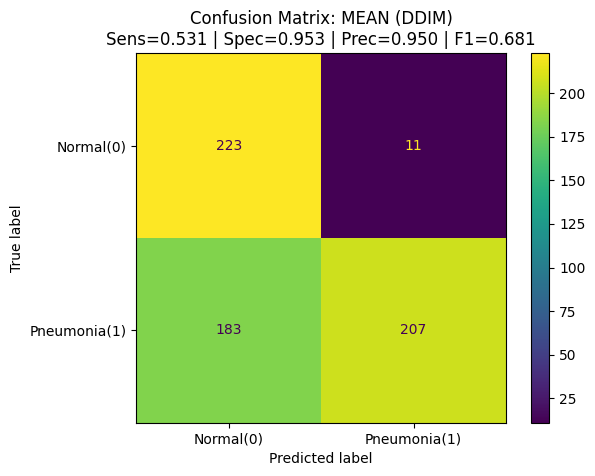

In [30]:
# New combined code for caching and analyzing DDIM scores with multiple top-k ratios, including helper functions and final evaluation report.
# Helper function to create valid keys for top-k ratios (e.g., 0.01 -> "0p01")

def ratio_key(r: float) -> str:
    # 0.005 -> "0p005", 0.01 -> "0p01"
    s = f"{r:.6f}".rstrip("0").rstrip(".")
    return s.replace(".", "p")

def threshold_at_specificity(y, scores, target_spec=0.95):
    fpr, tpr, thr = roc_curve(y, scores)
    spec = 1 - fpr

    valid = np.where(spec >= target_spec)[0]
    if len(valid) == 0:
        i = int(np.argmin(np.abs(spec - target_spec)))
        return thr[i], spec[i], tpr[i]

    i_best = valid[np.argmax(tpr[valid])]
    return thr[i_best], spec[i_best], tpr[i_best]

@torch.no_grad()
def cache_scores_ddim(cache_path, model, device, test_loader, alphas_cumprod,T_START=400, DDIM_STEPS=50, ETA=0.0, TOPK_RATIOS=[0.005, 0.01, 0.02, 0.05]):
    model.eval()

    y_all = []
    mean_all = []
    topk_all = {r: [] for r in TOPK_RATIOS}
    
    print(f"DDIM Reconstruction on {device} from t={T_START} with eta={ETA}...")
    
    for x, lbl in tqdm(test_loader, desc="Caching DDIM scores"):
        x = x.to(device)  # [B,1,H,W]

        # labels to int array
        if isinstance(lbl, torch.Tensor):
            y_batch = lbl.view(-1).cpu().numpy().astype(int)
        else:
            y_batch = np.array(lbl).astype(int)

        # DDIM reconstruction (heal from t_start down)
        recon = ddim_reconstruct_from_tstart(
            model=model,
            x0=x,
            alphas_cumprod=alphas_cumprod,
            t_start=T_START,
            ddim_steps=DDIM_STEPS,
            eta=ETA,
            device=device
        )
        # Residual per pixel: [B,1,H,W] -> [B, P] where P=H*W
        resid = (x - recon).abs().view(x.size(0), -1)
        # Mean score pre image (average pixel error)
        mean_scores = resid.mean(dim=1).detach().cpu().numpy()

        # top-k scores by ratio
        P = resid.size(1)
        for r in TOPK_RATIOS:
            k = max(1, int(r * P))
            vals, _ = torch.topk(resid, k=k, dim=1, largest=True, sorted=False)
            score = vals.mean(dim=1).detach().cpu().numpy()
            topk_all[r].append(score)

        y_all.append(y_batch)
        mean_all.append(mean_scores)

    # Concatanate all batches into single arrays for labels and scores
    y = np.concatenate(y_all, axis=0)
    mean_scores = np.concatenate(mean_all, axis=0)
    # Concatenate TOPK
    topk_concat = {r: np.concatenate(topk_all[r], axis=0).astype(np.float32) for r in TOPK_RATIOS}

    # Direction check: ensure higher score means more likely pneumonia (label 1)
    m_pos = mean_scores[y == 1].mean()
    m_neg = mean_scores[y == 0].mean()
    score_flip = bool(m_pos < m_neg)
    
    if score_flip:
        mean_scores = -mean_scores
        for r in TOPK_RATIOS:
            topk_concat[r] = -topk_concat[r]
    
    # Build the dictionary to save, including metadata and all score arrays
    save_dict = {
        "y": y,
        "mean_scores": mean_scores,
        "t_start": T_START,
        "ddim_steps": DDIM_STEPS,
        "eta": ETA,
        "topk_ratios": np.array(TOPK_RATIOS, dtype=np.float32),
        "store_fliped": int(score_flip)
    }

    # Add top-k score arrays to the save dictionary with keys like "topk_0p01" for 1% top-k scores
    for r in TOPK_RATIOS:
        key = f"topk_{ratio_key(r)}"
        save_dict[key] = topk_concat[r]

    np.savez(cache_path, **save_dict)

    print("Saved:", cache_path)
    print("y:", y.shape, "mean_scores:", mean_scores.shape)
    for r in TOPK_RATIOS:
        key = f"topk_{ratio_key(r)}"
        print(key, save_dict[key].shape)


def analyze_cached_scores(cache_path, target_spec=0.95):
    data = np.load(cache_path, allow_pickle=True)
    print("Keys in cache:", sorted(data.files))

    y = data["y"].astype(int)
    n = len(y)
    
    methods = {}
    methods["MEAN"] = data["mean_scores"].astype(float)

    topk_keys = sorted([k for k in data.files if k.startswith("topk_") and k != "topk_ratios"])

    for k in topk_keys:
        arr = np.array(data[k])
        # keep only real score arrays: 1D and length == len(y)
        if arr.ndim == 1 and len(arr) == n:
            methods[k.upper()] = arr.astype(float)
        else:
            print(f"Skipping key {k} (shape {arr.shape})")

    print("Methods included:", list(methods.keys()))

    # ---- AUROC + AUPRC Summary Table ----
    print("\nEvaluation Summary:")
    print(f"  {'Method':<14} {'AUROC':>8} {'AUPRC':>8}")
    print(f"  {'-'*32}")

    summary = []
    aurocs = {}
    for name, s in methods.items():
        auroc = roc_auc_score(y, s)
        auprc = average_precision_score(y, s)
        aurocs[name] = auroc
        summary.append((name, auroc, auprc))
        print(f"  {name:<14} {auroc:>8.4f} {auprc:>8.4f}")

    print(f"  {'-'*32}")
    best_overall = max(summary, key=lambda x: (x[1] + x[2]) / 2)
    print(f"  {'Best':<14} {best_overall[1]:>8.4f} {best_overall[2]:>8.4f}  <- {best_overall[0]}")

    best_name = best_overall[0]

    # ---- ROC plot ----
    plt.figure(figsize=(7, 6))
    for name, s in methods.items():
        fpr, tpr, _ = roc_curve(y, s)
        plt.plot(fpr, tpr, label=f"{name} (AUC={aurocs[name]:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title("ROC Curves (DDIM cache)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Precision-Recall Curves ---
    plt.figure(figsize=(7, 6))
    for name, s in methods.items():
        prec, rec, _ = precision_recall_curve(y, s)
        auprc = average_precision_score(y, s)
        plt.plot(rec, prec, lw=2, label=f"{name} (AUPRC={auprc:.3f})")

    baseline = y.sum() / len(y)
    plt.axhline(baseline, linestyle="--", lw=2, label=f"Random baseline ({baseline:.2f})")

    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves (DDIM)")
    plt.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ---- Confusion matrices: MEAN + BEST method @ target specificity ----
    best_name = max(aurocs, key=aurocs.get)
    print("\nBest method by AUROC:", best_name, "AUC=", aurocs[best_name])

    for name in ["MEAN", best_name] if best_name != "MEAN" else ["MEAN"]:
        s = methods[name]
        thr, spec, tpr = threshold_at_specificity(y, s, target_spec=target_spec)
        y_pred = (s >= thr).astype(int)

        # Compute confusion matrix and metrics
        cm = confusion_matrix(y, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp + 1e-12)
        f1        = 2 * (precision * tpr) / (precision + tpr + 1e-12)
        acc       = (tp + tn) / (tp + tn + fp + fn + 1e-12)
        
        # Print metrics report
        print(f"\n--- {name} @ {target_spec*100:.0f}% Specificity ---")
        print(f"  Threshold  : {thr:.6f}")
        print(f"  Sensitivity: {tpr:.3f}  (sick cases caught)")
        print(f"  Specificity: {spec:.3f}  (healthy cases correctly cleared)")
        print(f"  Precision  : {precision:.3f}  (of flagged, how many truly sick)")
        print(f"  F1 Score   : {f1:.3f}")
        print(f"  Accuracy   : {acc:.3f}")

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Pneumonia(1)"])
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix: {name} (DDIM)\nSens={tpr:.3f} | Spec={spec:.3f} | Prec={precision:.3f} | F1={f1:.3f}")
        plt.show()  


# Match DDPM Top-K style: ratios -> dynamic k (0.01 means top 1% pixels with highest error)
TOPK_RATIOS = [0.005, 0.01, 0.02, 0.05]
TARGET_SPEC = 0.95
CACHE_PATH_DDIM = "cache/cached_scores_ddim_t400_s100_eta0_multi_topk_updated.npz"

if os.path.exists(CACHE_PATH_DDIM):
    print(f"Loading cached scores from {CACHE_PATH_DDIM}")
    analyze_cached_scores(CACHE_PATH_DDIM, target_spec=TARGET_SPEC)
else:
    print(f"Cache not found at {CACHE_PATH_DDIM}. Running DDIM reconstruction and caching scores...")
    cache_scores_ddim(
        cache_path=CACHE_PATH_DDIM,
        model=model,
        device=device,
        test_loader=test_loader,
        alphas_cumprod=alphas_cumprod,
        T_START=400,
        DDIM_STEPS=100,
        ETA=0.0,
        TOPK_RATIOS=TOPK_RATIOS
    )
    analyze_cached_scores(CACHE_PATH_DDIM, target_spec=TARGET_SPEC)